<div style="background: linear-gradient(135deg, #0f172a 0%, #1e293b 50%, #334155 100%); padding: 40px 30px; border-radius: 16px; margin-bottom: 20px; border: 1px solid #475569; box-shadow: 0 20px 40px rgba(0,0,0,0.3);">
    <div style="text-align: center;">
        <h1 style="color: #f8fafc;text-align: center; font-size: 36px; margin: 0; letter-spacing: 1px;">Customer Churn Prediction</h1>
        <p style="color: #94a3b8;text-align: center; font-size: 18px; margin-top: 8px; font-weight: 300;">Kaggle Playground Series - Season 6 Episode 3</p>
        <hr style="border: none;text-align: center; height: 3px; background: linear-gradient(90deg, transparent, #3b82f6, #8b5cf6, #ec4899, transparent); margin: 20px auto; width: 80%;">
        <p style="color: #e2e8f0;text-align: center; font-size: 15px; margin: 0;"><strong style="color: #3b82f6;">Two-Stage Ridge → XGBoost</strong> with <strong style="color: #8b5cf6;">Bi-gram/Tri-gram</strong> Target Encoding</p>
    </div>
</div>

# Two-Stage Ridge → XGBoost for Customer Churn Prediction

This notebook implements a **two-stage learning pipeline** for predicting customer churn:

- **Stage 1 (Ridge)**: Linear model captures simple linear patterns and relationships
- **Stage 2 (XGBoost)**: Tree-based model focuses on non-linear corrections, using Ridge predictions as an additional feature

### Why Two-Stage Learning?

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **Ridge** | Linear patterns, stable, fast | Cannot capture non-linear relationships |
| **XGBoost** | Non-linear patterns, interactions | May overfit to simple linear signals |
| **Ridge → XGB** | Best of both worlds | XGB corrects Ridge's mistakes |

### Key Features:
- **Bi-gram and Tri-gram Composite Categorical Features**: Capturing 2-way and 3-way feature interactions
- **Inner K-Fold Target Encoding**: Preventing data leakage in categorical encoding
- **Comprehensive Feature Engineering**: 7-step pipeline with 150+ features

# 1. Problem Statement

<div style="background:#f1f5f9; padding:20px; border-radius:10px; border-left:4px solid #3b82f6;">

<h3 style="margin-top:0;">Objective</h3>

Predict whether a customer will churn based on demographic information, account details, and subscribed services.

</div>

---

## Business Context

Customer churn is a key performance metric for telecom companies.  
Acquiring new customers is significantly more expensive than retaining existing ones.

Accurate churn prediction allows companies to:

- Identify **customers at risk of leaving**
- Offer **targeted retention incentives**
- Understand **drivers of customer dissatisfaction**
- Optimize **customer support and retention strategies**

---

## Evaluation Metric

<div style="background:#ecfdf5; padding:20px; border-radius:10px; border-left:4px solid #10b981;">

<h4 style="margin-top:0;">ROC-AUC (Receiver Operating Characteristic – Area Under Curve)</h4>

ROC-AUC measures the model's ability to distinguish between churners and non-churners across all classification thresholds.

</div>

### Interpretation

| AUC Score | Interpretation |
|-----------|---------------|
| **0.50** | Random guessing |
| **0.70 – 0.80** | Acceptable model |
| **0.80 – 0.90** | Strong predictive performance |
| **> 0.90** | Excellent discrimination |

A higher ROC-AUC indicates better ranking ability between churn and non-churn customers.

## Machine Learning Pipeline

<div style="background: #f8fafc; padding: 30px; border-radius: 12px; text-align: center; font-family: monospace; font-size: 14px;">

```
┌─────────────────┐    ┌─────────────────┐    ┌─────────────────┐    ┌─────────────────┐
│  DATA LOADING   │ ──▶│       EDA       │ ──▶│    CLEANING     │ ──▶│    FEATURES     │
│  Train/Test/Orig│    │   Distributions │    │  Missing Values │    │  7-Step Pipeline│
└─────────────────┘    └─────────────────┘    └─────────────────┘    └─────────────────┘
                                                                              │
                                                                              ▼
┌─────────────────┐    ┌─────────────────┐    ┌─────────────────┐    ┌─────────────────┐
│   SUBMISSION    │ ◀──│   XGB STAGE 2   │ ◀──│  RIDGE STAGE 1  │ ◀──│  N-GRAM ENCODING│
│  CSV Files      │    │  + Ridge Feat   │    │  Linear Model   │    │  Bi/Tri-grams   │
└─────────────────┘    └─────────────────┘    └─────────────────┘    └─────────────────┘
```

</div>

<div class="alert alert-info" style="border-radius: 8px; padding: 15px; margin-top: 20px; background: #eff6ff; border: 1px solid #3b82f6;">
    <b style="color: #1e40af;">Two-Stage Strategy:</strong> <span style="color: #1e3a8a;">Ridge captures linear patterns first, then XGBoost uses those predictions as a feature to focus on learning non-linear corrections. This "simple → complex" staged learning often outperforms single models.</span>
</div>

---
## 2. Dataset Description and Loading

### Data Sources
- **Training Set**: Labeled customer data for model training
- **Test Set**: Unlabeled data for prediction submission
- **Original Dataset**: Additional historical data from WA_Fn-UseC_-Telco-Customer-Churn.csv

### Features Overview
| Category | Features | Description |
|----------|----------|-------------|
| **Demographics** | gender, SeniorCitizen, Partner, Dependents | Customer profile information |
| **Services** | PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies | Subscribed services |
| **Account** | tenure, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges | Account and billing information |
| **Target** | Churn | Whether customer left (Yes/No) |

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import warnings
import gc
import time
from itertools import combinations

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
import xgboost as xgb
from scipy import sparse

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Configuration
class CFG:
    TARGET = 'Churn'
    N_FOLDS = 20       # Outer CV folds
    INNER_FOLDS = 5    # Inner CV folds for target encoding
    RANDOM_SEED = 42
    RIDGE_ALPHA = 10.0  # L2 regularization for Ridge
    
    # Data paths (update these paths as needed)
    TRAIN_PATH = "/kaggle/input/competitions/playground-series-s6e3/train.csv"
    TEST_PATH = "/kaggle/input/competitions/playground-series-s6e3/test.csv"
    ORIGINAL_PATH = "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Top categoricals for bi-gram/tri-gram combinations (by feature importance)
TOP_CATS_FOR_NGRAM = [
    'Contract', 'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling'
]

# XGBoost Parameters (Optuna-optimized)
XGB_PARAMS = {
    'n_estimators': 50000,
    'learning_rate': 0.0063,
    'max_depth': 5,
    'subsample': 0.81,
    'colsample_bytree': 0.32,
    'min_child_weight': 6,
    'reg_alpha': 3.5017,
    'reg_lambda': 1.2925,
    'gamma': 0.790,
    'random_state': CFG.RANDOM_SEED,
    'early_stopping_rounds': 500,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'enable_categorical': True,
    'device': 'cuda',
    'verbosity': 0,
}

print("Configuration set!")
print(f"  N_FOLDS: {CFG.N_FOLDS}")
print(f"  RIDGE_ALPHA: {CFG.RIDGE_ALPHA}")

Configuration set!
  N_FOLDS: 20
  RIDGE_ALPHA: 10.0


In [3]:
# Load Data
print("Loading datasets...")
train = pd.read_csv(CFG.TRAIN_PATH)
test = pd.read_csv(CFG.TEST_PATH)
orig = pd.read_csv(CFG.ORIGINAL_PATH)

# Encode target variable
train[CFG.TARGET] = train[CFG.TARGET].map({'No': 0, 'Yes': 1}).astype(int)
orig[CFG.TARGET] = orig[CFG.TARGET].map({'No': 0, 'Yes': 1}).astype(int)

# Handle TotalCharges in original data
orig['TotalCharges'] = pd.to_numeric(orig['TotalCharges'], errors='coerce')
orig['TotalCharges'].fillna(orig['TotalCharges'].median(), inplace=True)

# Remove customer ID if present
if 'customerID' in orig.columns:
    orig.drop(columns=['customerID'], inplace=True)

# Store IDs for later
train_ids = train['id'].copy()
test_ids = test['id'].copy()

print(f"Train Shape : {train.shape}")
print(f"Test Shape  : {test.shape}")
print(f"Original Shape: {orig.shape}")

Loading datasets...
Train Shape : (594194, 21)
Test Shape  : (254655, 20)
Original Shape: (7043, 20)


---
## 3. Exploratory Data Analysis (EDA)

Let's explore the dataset to understand the distributions, relationships, and patterns in the data.

In [4]:
# Dataset Overview
print("="*60)
print("TRAINING DATA OVERVIEW")
print("="*60)
display(train.head())

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(train.dtypes.to_frame('dtype'))

TRAINING DATA OVERVIEW


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1



DATA TYPES
                    dtype
id                  int64
gender             object
SeniorCitizen       int64
Partner            object
Dependents         object
tenure              int64
PhoneService       object
MultipleLines      object
InternetService    object
OnlineSecurity     object
OnlineBackup       object
DeviceProtection   object
TechSupport        object
StreamingTV        object
StreamingMovies    object
Contract           object
PaperlessBilling   object
PaymentMethod      object
MonthlyCharges    float64
TotalCharges      float64
Churn               int64


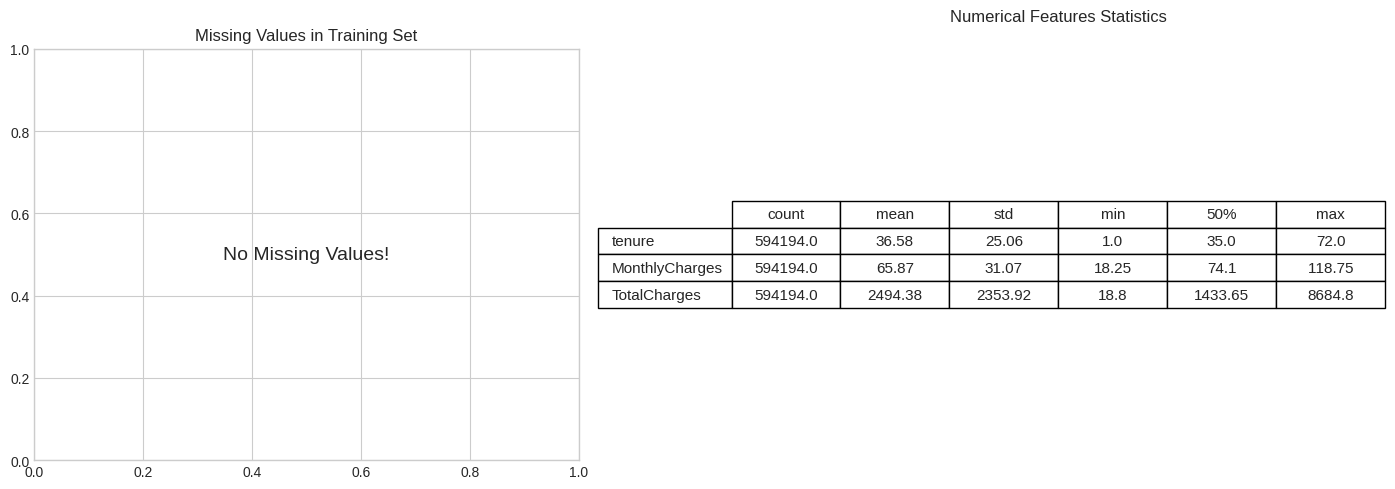

In [5]:
# Missing Values Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set missing values
train_missing = train.isnull().sum()
train_missing = train_missing[train_missing > 0]
if len(train_missing) > 0:
    axes[0].barh(train_missing.index, train_missing.values, color='coral')
    axes[0].set_xlabel('Missing Count')
    axes[0].set_title('Missing Values in Training Set')
else:
    axes[0].text(0.5, 0.5, 'No Missing Values!', ha='center', va='center', fontsize=14)
    axes[0].set_title('Missing Values in Training Set')

# Numerical statistics
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
stats_df = train[num_cols].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
axes[1].axis('off')
table = axes[1].table(cellText=stats_df.round(2).values,
                       rowLabels=stats_df.index,
                       colLabels=stats_df.columns,
                       cellLoc='center',
                       loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)
axes[1].set_title('Numerical Features Statistics', fontsize=12, pad=20)

plt.tight_layout()
plt.show()

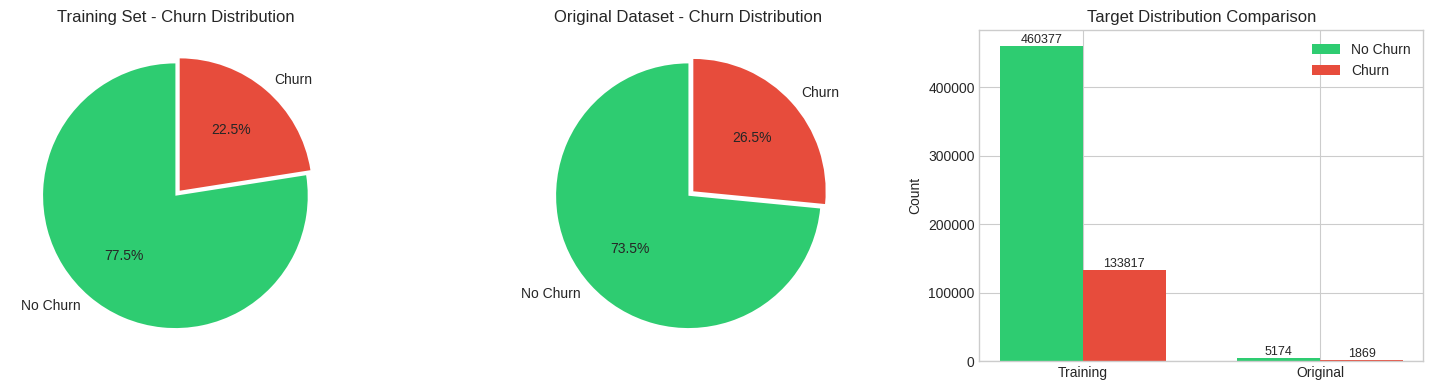


Churn Rate - Training: 22.52%
Churn Rate - Original: 26.54%


In [6]:
# Target Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training set target
train_churn = train[CFG.TARGET].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(train_churn.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[0].set_title('Training Set - Churn Distribution')

# Original dataset target
orig_churn = orig[CFG.TARGET].value_counts()
axes[1].pie(orig_churn.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[1].set_title('Original Dataset - Churn Distribution')

# Comparison bar chart
x = np.arange(2)
width = 0.35
bars1 = axes[2].bar(x - width/2, [train_churn[0], orig_churn[0]], width, label='No Churn', color='#2ecc71')
bars2 = axes[2].bar(x + width/2, [train_churn[1], orig_churn[1]], width, label='Churn', color='#e74c3c')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Training', 'Original'])
axes[2].set_ylabel('Count')
axes[2].set_title('Target Distribution Comparison')
axes[2].legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[2].annotate(f'{int(height)}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nChurn Rate - Training: {train[CFG.TARGET].mean()*100:.2f}%")
print(f"Churn Rate - Original: {orig[CFG.TARGET].mean()*100:.2f}%")

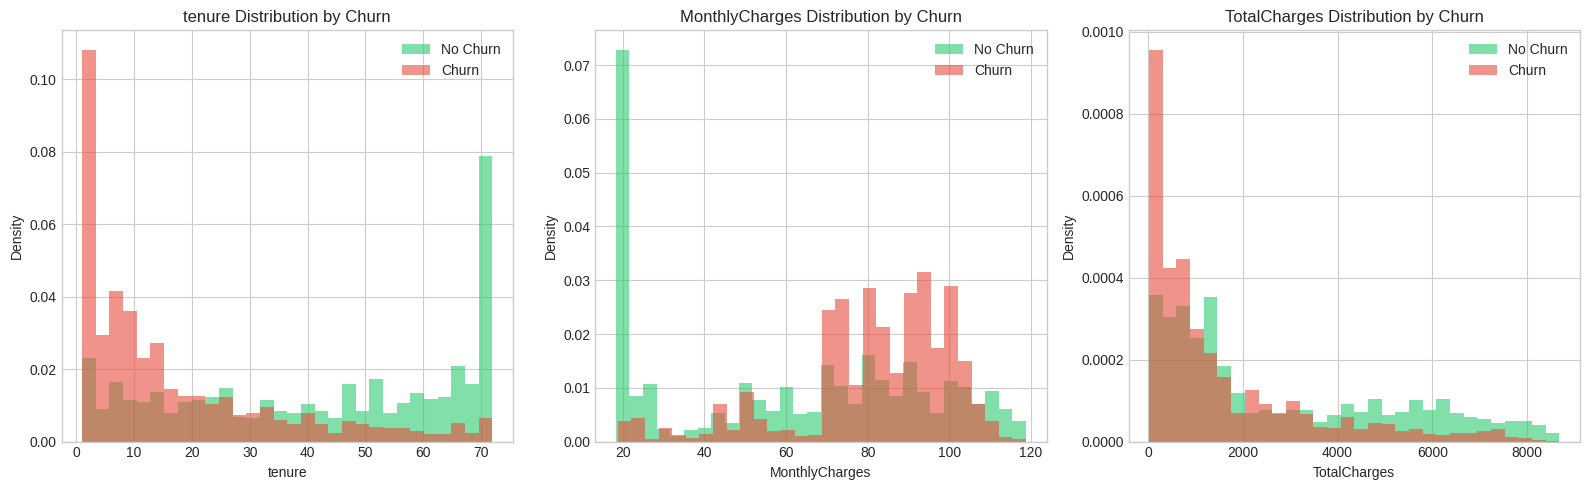


Key Observations:
  - Tenure: Churners tend to have shorter tenure
  - MonthlyCharges: Churners often have higher monthly charges
  - TotalCharges: Churners typically have lower total charges (correlated with tenure)


In [7]:
# Numerical Features Distribution by Churn
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    for churn_val, label, color in [(0, 'No Churn', '#2ecc71'), (1, 'Churn', '#e74c3c')]:
        data = train[train[CFG.TARGET] == churn_val][col]
        axes[idx].hist(data, bins=30, alpha=0.6, label=label, color=color, density=True)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')
    axes[idx].set_title(f'{col} Distribution by Churn')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("  - Tenure: Churners tend to have shorter tenure")
print("  - MonthlyCharges: Churners often have higher monthly charges")
print("  - TotalCharges: Churners typically have lower total charges (correlated with tenure)")

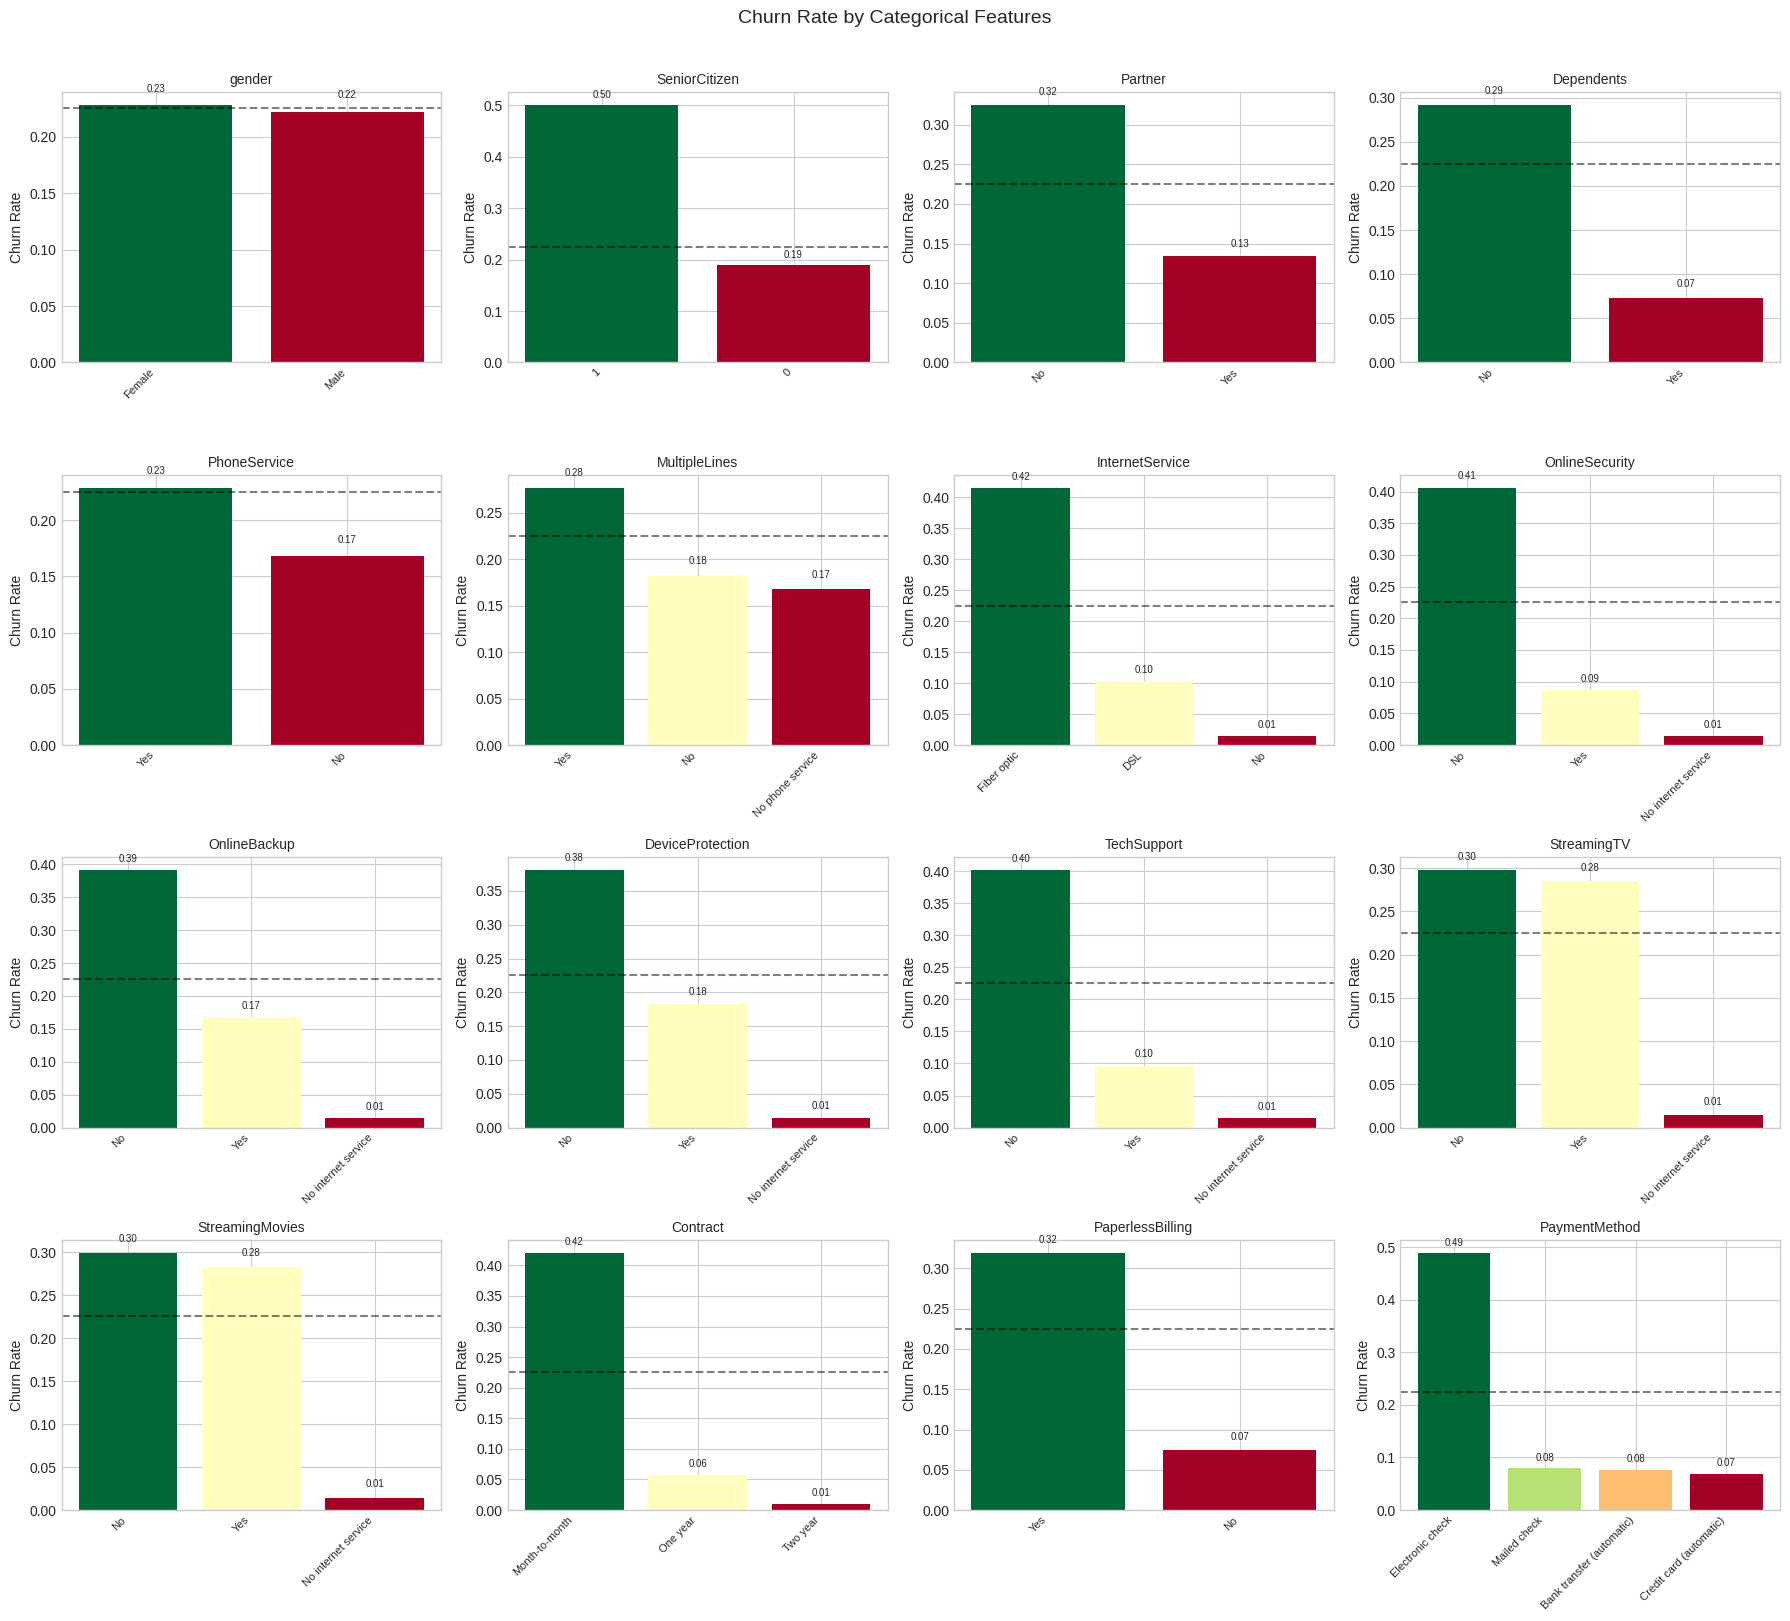

In [8]:
# Categorical Features Analysis
CATS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for idx, col in enumerate(CATS):
    # Calculate churn rate by category
    churn_rate = train.groupby(col)[CFG.TARGET].mean().sort_values(ascending=False)
    
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(churn_rate)))
    bars = axes[idx].bar(range(len(churn_rate)), churn_rate.values, color=colors)
    axes[idx].set_xticks(range(len(churn_rate)))
    axes[idx].set_xticklabels(churn_rate.index, rotation=45, ha='right', fontsize=8)
    axes[idx].set_ylabel('Churn Rate')
    axes[idx].set_title(f'{col}', fontsize=10)
    axes[idx].axhline(y=train[CFG.TARGET].mean(), color='black', linestyle='--', alpha=0.5)
    
    # Add value labels
    for bar, val in zip(bars, churn_rate.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                      f'{val:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

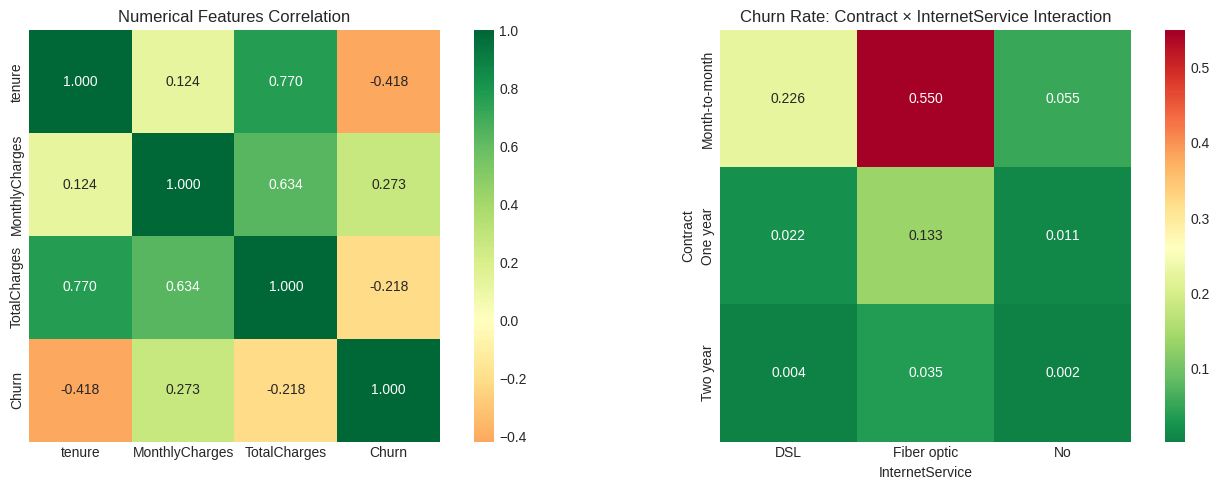


Note: Strong interaction between Contract type and InternetService!
This justifies using bi-gram/tri-gram composite features.


In [9]:
# Correlation Matrix for Numerical Features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Numerical correlation
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = train[num_cols + [CFG.TARGET]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, ax=axes[0], 
            fmt='.3f', square=True)
axes[0].set_title('Numerical Features Correlation')

# Contract vs InternetService churn rates (important interaction)
pivot = train.pivot_table(values=CFG.TARGET, index='Contract', 
                          columns='InternetService', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='RdYlGn_r', center=0.26, ax=axes[1], 
            fmt='.3f', square=True)
axes[1].set_title('Churn Rate: Contract × InternetService Interaction')

plt.tight_layout()
plt.show()

print("\nNote: Strong interaction between Contract type and InternetService!")
print("This justifies using bi-gram/tri-gram composite features.")

### Key Insights from EDA

<div class="alert alert-success" style="border-radius: 8px; padding: 20px; background: #ecfdf5; border: 1px solid #10b981;">

<h4 style="margin-top:0; color:#047857;">Key Findings</h4>

<ul>

<li><strong>Class Imbalance:</strong> The dataset contains ~26% churned customers, representing a moderate class imbalance. Evaluation metrics such as ROC-AUC are preferable over accuracy.</li>

<li><strong>Contract Type:</strong> Contract length is the strongest predictor of churn. Month-to-month customers exhibit very high churn rates (~42%) compared to two-year contracts (~3%).</li>

<li><strong>Customer Tenure:</strong> Churn is concentrated among newer customers. The probability of churn decreases significantly as tenure increases.</li>

<li><strong>Internet Service:</strong> Customers with fiber optic internet show higher churn rates compared to DSL or customers without internet service.</li>

<li><strong>Payment Method:</strong> Electronic check users demonstrate elevated churn levels, potentially indicating less stable payment behavior.</li>

<li><strong>Service Adoption:</strong> Customers without additional services such as <strong>OnlineSecurity</strong> or <strong>TechSupport</strong> are significantly more likely to churn.</li>

<li><strong>Feature Relationships:</strong> TotalCharges is strongly correlated with tenure, which is expected since total billing accumulates over time.</li>

<li><strong>Pricing Patterns:</strong> Higher MonthlyCharges are associated with increased churn, though this effect is partially driven by fiber optic subscriptions.</li>

</ul>

</div>

---
## 4. Feature Engineering

### Feature Engineering Pipeline

The feature engineering pipeline consists of the following components:

| Step | Feature Type | Description |
|------|--------------|-------------|
| 1 | Frequency Encoding | Frequency of numerical values across train/test/orig |
| 2 | Arithmetic Interactions | Derived ratios and deviations |
| 3 | Service Counts | Aggregation of service subscriptions |
| 4 | ORIG_proba | Target encoding from original dataset |
| 5 | Distribution Features | Percentile ranks, z-scores against churn/non-churn distributions |
| 6 | Quantile Distance | Distance to quantiles of churner/non-churner distributions |
| 7 | N-gram Composite | **Bi-gram and Tri-gram categorical target encoding** |

In [10]:
# Define Feature Groups
CATS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
NUMS = ['tenure', 'MonthlyCharges', 'TotalCharges']

NEW_NUMS = []
NUM_AS_CAT = []

print("Feature Engineering Pipeline Started...")
print("="*60)

Feature Engineering Pipeline Started...


In [11]:
# 1. Frequency Encoding
print("[1/7] Creating Frequency Encoding features...")
for col in NUMS:
    freq = pd.concat([train[col], orig[col]]).value_counts(normalize=True)
    for df in [train, test, orig]:
        df[f'FREQ_{col}'] = df[col].map(freq).fillna(0).astype('float32')
    NEW_NUMS.append(f'FREQ_{col}')
print(f"    Created {len(NUMS)} frequency features")

[1/7] Creating Frequency Encoding features...
    Created 3 frequency features


In [12]:
# 2. Arithmetic Interactions
print("[2/7] Creating Arithmetic Interaction features...")
for df in [train, test, orig]:
    df['charges_deviation'] = (df['TotalCharges'] - df['tenure'] * df['MonthlyCharges']).astype('float32')
    df['monthly_to_total_ratio'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1)).astype('float32')
    df['avg_monthly_charges'] = (df['TotalCharges'] / (df['tenure'] + 1)).astype('float32')
NEW_NUMS += ['charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges']
print(f"    Created 3 arithmetic features")

[2/7] Creating Arithmetic Interaction features...
    Created 3 arithmetic features


In [13]:
# 3. Service Counts
print("[3/7] Creating Service Count features...")
SERVICE_COLS = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for df in [train, test, orig]:
    df['service_count'] = (df[SERVICE_COLS] == 'Yes').sum(axis=1).astype('float32')
    df['has_internet'] = (df['InternetService'] != 'No').astype('float32')
    df['has_phone'] = (df['PhoneService'] == 'Yes').astype('float32')
NEW_NUMS += ['service_count', 'has_internet', 'has_phone']
print(f"    Created 3 service count features")

[3/7] Creating Service Count features...
    Created 3 service count features


In [14]:
# 4. ORIG_proba Mapping
print("[4/7] Creating ORIG_proba features (target probability from original data)...")
for col in CATS + NUMS:
    tmp = orig.groupby(col)[CFG.TARGET].mean()
    _name = f"ORIG_proba_{col}"
    train = train.merge(tmp.rename(_name), on=col, how="left")
    test = test.merge(tmp.rename(_name), on=col, how="left")
    for df in [train, test]:
        df[_name] = df[_name].fillna(0.5).astype('float32')
    NEW_NUMS.append(_name)
print(f"    Created {len(CATS + NUMS)} ORIG_proba features")

[4/7] Creating ORIG_proba features (target probability from original data)...
    Created 19 ORIG_proba features


In [15]:
# 5. Distribution Features
print("[5/7] Creating Distribution Features (percentile ranks, z-scores)...")

def pctrank_against(values, reference):
    ref_sorted = np.sort(reference)
    return (np.searchsorted(ref_sorted, values) / len(ref_sorted)).astype('float32')

def zscore_against(values, reference):
    mu, sigma = np.mean(reference), np.std(reference)
    return (np.zeros(len(values), dtype='float32') if sigma == 0 
            else ((values - mu) / sigma).astype('float32'))

orig_churner_tc    = orig.loc[orig[CFG.TARGET] == 1, 'TotalCharges'].values
orig_nonchurner_tc = orig.loc[orig[CFG.TARGET] == 0, 'TotalCharges'].values
orig_tc            = orig['TotalCharges'].values
orig_is_mc_mean    = orig.groupby('InternetService')['MonthlyCharges'].mean()

for df in [train, test]:
    tc = df['TotalCharges'].values
    df['pctrank_nonchurner_TC']  = pctrank_against(tc, orig_nonchurner_tc)
    df['pctrank_churner_TC']     = pctrank_against(tc, orig_churner_tc)
    df['pctrank_orig_TC']        = pctrank_against(tc, orig_tc)
    df['zscore_churn_gap_TC'] = (np.abs(zscore_against(tc, orig_churner_tc)) - 
                                 np.abs(zscore_against(tc, orig_nonchurner_tc))).astype('float32')
    df['zscore_nonchurner_TC'] = zscore_against(tc, orig_nonchurner_tc)
    df['pctrank_churn_gap_TC'] = (pctrank_against(tc, orig_churner_tc) - 
                                  pctrank_against(tc, orig_nonchurner_tc)).astype('float32')
    df['resid_IS_MC'] = (df['MonthlyCharges'] - df['InternetService'].map(orig_is_mc_mean).fillna(0)).astype('float32')
    
    vals = np.zeros(len(df), dtype='float32')
    for cat_val in orig['InternetService'].unique():
        mask = df['InternetService'] == cat_val
        ref = orig.loc[orig['InternetService'] == cat_val, 'TotalCharges'].values
        if len(ref) > 0 and mask.sum() > 0:
            vals[mask] = pctrank_against(df.loc[mask, 'TotalCharges'].values, ref)
    df['cond_pctrank_IS_TC'] = vals
    
    vals = np.zeros(len(df), dtype='float32')
    for cat_val in orig['Contract'].unique():
        mask = df['Contract'] == cat_val
        ref = orig.loc[orig['Contract'] == cat_val, 'TotalCharges'].values
        if len(ref) > 0 and mask.sum() > 0:
            vals[mask] = pctrank_against(df.loc[mask, 'TotalCharges'].values, ref)
    df['cond_pctrank_C_TC'] = vals

DIST_FEATURES = [
    'pctrank_nonchurner_TC', 'zscore_churn_gap_TC', 'pctrank_churn_gap_TC',
    'resid_IS_MC', 'cond_pctrank_IS_TC', 'zscore_nonchurner_TC',
    'pctrank_orig_TC', 'pctrank_churner_TC', 'cond_pctrank_C_TC'
]
NEW_NUMS += DIST_FEATURES
print(f"    Created {len(DIST_FEATURES)} distribution features")

[5/7] Creating Distribution Features (percentile ranks, z-scores)...
    Created 9 distribution features


In [16]:
# 6. Quantile Distance Features
print("[6/7] Creating Quantile Distance Features...")
for q_label, q_val in [('q25', 0.25), ('q50', 0.50), ('q75', 0.75)]:
    ch_q = np.quantile(orig_churner_tc, q_val)
    nc_q = np.quantile(orig_nonchurner_tc, q_val)
    for df in [train, test]:
        df[f'dist_To_ch_{q_label}'] = np.abs(df['TotalCharges'] - ch_q).astype('float32')
        df[f'dist_To_nc_{q_label}'] = np.abs(df['TotalCharges'] - nc_q).astype('float32')
        df[f'qdist_gap_To_{q_label}'] = (df[f'dist_To_nc_{q_label}'] - df[f'dist_To_ch_{q_label}']).astype('float32')

QDIST_FEATURES = [
    'qdist_gap_To_q50', 'dist_To_ch_q50', 'dist_To_nc_q50',
    'dist_To_nc_q25', 'qdist_gap_To_q25',
    'dist_To_nc_q75', 'dist_To_ch_q75', 'qdist_gap_To_q75'
]
NEW_NUMS += QDIST_FEATURES
print(f"    Created {len(QDIST_FEATURES)} quantile distance features")

[6/7] Creating Quantile Distance Features...
    Created 8 quantile distance features


In [17]:
# 7. Numericals as Categories
print("[7/7] Creating Numericals-as-Categories features...")
for col in NUMS:
    _new = f'CAT_{col}'
    NUM_AS_CAT.append(_new)
    for df in [train, test]:
        df[_new] = df[col].astype(str).astype('category')
print(f"    Created {len(NUMS)} numerical-as-category features")

[7/7] Creating Numericals-as-Categories features...
    Created 3 numerical-as-category features


In [18]:
# Digit Features
DIGIT_FEATURES = [
    # Tenure
    'tenure_first_digit','tenure_last_digit','tenure_second_digit',
    'tenure_mod10','tenure_mod12','tenure_num_digits',
    'tenure_is_multiple_10','tenure_rounded_10','tenure_dev_from_round10',

    # MonthlyCharges
    'mc_first_digit','mc_last_digit','mc_second_digit',
    'mc_mod10','mc_mod100','mc_num_digits',
    'mc_is_multiple_10','mc_is_multiple_50',
    'mc_rounded_10','mc_fractional','mc_dev_from_round10',

    # TotalCharges
    'tc_first_digit','tc_last_digit','tc_second_digit',
    'tc_mod10','tc_mod100','tc_num_digits',
    'tc_is_multiple_10','tc_is_multiple_100',
    'tc_rounded_100','tc_fractional','tc_dev_from_round100',

    # Derived
    'tenure_years','tenure_months_in_year',
    'mc_per_digit','tc_per_digit'
]

for df in [train, test]:

    # Tenure digits
    t_str = df['tenure'].astype(str)
    df['tenure_first_digit'] = t_str.str[0].astype(int)
    df['tenure_last_digit'] = t_str.str[-1].astype(int)
    df['tenure_second_digit'] = t_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)

    df['tenure_mod10'] = df['tenure'] % 10
    df['tenure_mod12'] = df['tenure'] % 12
    df['tenure_num_digits'] = t_str.str.len()

    df['tenure_is_multiple_10'] = (df['tenure'] % 10 == 0).astype('float32')

    df['tenure_rounded_10'] = np.round(df['tenure']/10)*10
    df['tenure_dev_from_round10'] = abs(df['tenure'] - df['tenure_rounded_10'])

    # MonthlyCharges
    mc_str = df['MonthlyCharges'].astype(str).str.replace('.', '')

    df['mc_first_digit'] = mc_str.str[0].astype(int)
    df['mc_last_digit'] = mc_str.str[-1].astype(int)
    df['mc_second_digit'] = mc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)

    df['mc_mod10'] = np.floor(df['MonthlyCharges']) % 10
    df['mc_mod100'] = np.floor(df['MonthlyCharges']) % 100

    df['mc_num_digits'] = np.floor(df['MonthlyCharges']).astype(int).astype(str).str.len()

    df['mc_is_multiple_10'] = (np.floor(df['MonthlyCharges']) % 10 == 0).astype('float32')
    df['mc_is_multiple_50'] = (np.floor(df['MonthlyCharges']) % 50 == 0).astype('float32')

    df['mc_rounded_10'] = np.round(df['MonthlyCharges']/10)*10
    df['mc_fractional'] = df['MonthlyCharges'] - np.floor(df['MonthlyCharges'])
    df['mc_dev_from_round10'] = abs(df['MonthlyCharges'] - df['mc_rounded_10'])

    # TotalCharges
    tc_str = df['TotalCharges'].astype(str).str.replace('.', '')

    df['tc_first_digit'] = tc_str.str[0].astype(int)
    df['tc_last_digit'] = tc_str.str[-1].astype(int)
    df['tc_second_digit'] = tc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)

    df['tc_mod10'] = np.floor(df['TotalCharges']) % 10
    df['tc_mod100'] = np.floor(df['TotalCharges']) % 100

    df['tc_num_digits'] = np.floor(df['TotalCharges']).astype(int).astype(str).str.len()

    df['tc_is_multiple_10'] = (np.floor(df['TotalCharges']) % 10 == 0).astype('float32')
    df['tc_is_multiple_100'] = (np.floor(df['TotalCharges']) % 100 == 0).astype('float32')

    df['tc_rounded_100'] = np.round(df['TotalCharges']/100)*100
    df['tc_fractional'] = df['TotalCharges'] - np.floor(df['TotalCharges'])

    df['tc_dev_from_round100'] = abs(df['TotalCharges'] - df['tc_rounded_100'])

    # Derived
    df['tenure_years'] = df['tenure'] // 12
    df['tenure_months_in_year'] = df['tenure'] % 12

    df['mc_per_digit'] = df['MonthlyCharges']/(df['mc_num_digits']+0.001)
    df['tc_per_digit'] = df['TotalCharges']/(df['tc_num_digits']+0.001)

NEW_NUMS += DIGIT_FEATURES
print(f"    Created {len(DIGIT_FEATURES)} digit features")

    Created 35 digit features


In [19]:
# Create Bi-gram and Tri-gram Composite Categorical Features
print("\n" + "="*60)
print("Creating Bi-gram / Tri-gram Composite Features...")
print("="*60)

BIGRAM_COLS = []
TRIGRAM_COLS = []

# Bi-grams: all pairs from top 6 cats = C(6,2) = 15 pairs
print(f"\nCreating Bi-gram features from top {len(TOP_CATS_FOR_NGRAM)} categoricals:")
print(f"  Columns: {TOP_CATS_FOR_NGRAM}")
for c1, c2 in combinations(TOP_CATS_FOR_NGRAM, 2):
    col_name = f"BG_{c1}_{c2}"
    for df in [train, test]:
        df[col_name] = (df[c1].astype(str) + "_" + df[c2].astype(str)).astype('category')
    BIGRAM_COLS.append(col_name)

print(f"  Created {len(BIGRAM_COLS)} bi-gram features")

# Tri-grams: top 4 cats only to limit = C(4,3) = 4 triples
TOP4 = TOP_CATS_FOR_NGRAM[:4]
print(f"\nCreating Tri-gram features from top 4 categoricals:")
print(f"  Columns: {TOP4}")
for c1, c2, c3 in combinations(TOP4, 3):
    col_name = f"TG_{c1}_{c2}_{c3}"
    for df in [train, test]:
        df[col_name] = (df[c1].astype(str) + "_" + df[c2].astype(str) + "_" + df[c3].astype(str)).astype('category')
    TRIGRAM_COLS.append(col_name)

print(f"  Created {len(TRIGRAM_COLS)} tri-gram features")

NGRAM_COLS = BIGRAM_COLS + TRIGRAM_COLS
print(f"\nTotal N-gram features: {len(NGRAM_COLS)}")


Creating Bi-gram / Tri-gram Composite Features...

Creating Bi-gram features from top 6 categoricals:
  Columns: ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']
  Created 15 bi-gram features

Creating Tri-gram features from top 4 categoricals:
  Columns: ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity']
  Created 4 tri-gram features

Total N-gram features: 19


In [20]:
# Feature Summary
FEATURES = NUMS + CATS + NEW_NUMS + NUM_AS_CAT + NGRAM_COLS
TE_COLUMNS = NUM_AS_CAT + CATS
TE_NGRAM_COLUMNS = NGRAM_COLS
TO_REMOVE = NUM_AS_CAT + CATS + NGRAM_COLS
STATS = ['std', 'min', 'max']

print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)
print(f"Total Features: {len(FEATURES)}")
print(f"  - Numerical:            {len(NUMS)}")
print(f"  - Categorical:          {len(CATS)}")
print(f"  - Engineered Numerical: {len(NEW_NUMS)}")
print(f"  - Num-as-Cat:           {len(NUM_AS_CAT)}")
print(f"  - Bi-gram:              {len(BIGRAM_COLS)}")
print(f"  - Tri-gram:             {len(TRIGRAM_COLS)}")


FEATURE ENGINEERING COMPLETE
Total Features: 121
  - Numerical:            3
  - Categorical:          16
  - Engineered Numerical: 80
  - Num-as-Cat:           3
  - Bi-gram:              15
  - Tri-gram:             4


---
## 5. Two-Stage Model Training

### Two-Stage Learning Strategy

<div style="background: #fef3c7; padding: 20px; border-radius: 10px; border-left: 4px solid #f59e0b; margin: 15px 0;">

<h4 style="margin-top: 0; color: #92400e;">Stage 1: Ridge Regression (Linear Model)</h4>
<ul style="color: #78350f;">
<li>Captures linear patterns and relationships</li>
<li>Uses standardized numerical features + one-hot encoded categoricals</li>
<li>Fast training, stable predictions</li>
</ul>

<h4 style="margin-top: 15px; color: #92400e;">Stage 2: XGBoost (Non-linear Model)</h4>
<ul style="color: #78350f;">
<li>Uses Ridge predictions as an additional feature</li>
<li>Focuses on learning non-linear corrections</li>
<li>Can correct Ridge's mistakes</li>
</ul>

</div>

In [21]:
# Two-Stage Training: Ridge → XGB
print("\n" + "="*60)
print(f"TWO-STAGE TRAINING: RIDGE → XGB ({CFG.N_FOLDS}-FOLD CV)")
print("="*60)
print("  Stage 1: Ridge captures linear patterns")
print("  Stage 2: XGB focuses on non-linear corrections + Ridge hint")

np.random.seed(CFG.RANDOM_SEED)
skf_outer = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.RANDOM_SEED)
skf_inner = StratifiedKFold(n_splits=CFG.INNER_FOLDS, shuffle=True, random_state=CFG.RANDOM_SEED)

# Storage for both stages
ridge_oof = np.zeros(len(train))
ridge_pred = np.zeros(len(test))
xgb_oof = np.zeros(len(train))
xgb_pred = np.zeros(len(test))

ridge_fold_scores = []
xgb_fold_scores = []
feature_importances = pd.DataFrame()

t0_all = time.time()
t0 = time.time()

for i, (train_idx, val_idx) in enumerate(skf_outer.split(train, train[CFG.TARGET])):
    print(f"\n{'='*50}")
    print(f"Fold {i+1}/{CFG.N_FOLDS}")
    print(f"{'='*50}")
    
    X_tr  = train.loc[train_idx, FEATURES + [CFG.TARGET]].reset_index(drop=True).copy()
    y_tr  = train.loc[train_idx, CFG.TARGET].values
    X_val = train.loc[val_idx, FEATURES].reset_index(drop=True).copy()
    y_val = train.loc[val_idx, CFG.TARGET].values
    X_te  = test[FEATURES].reset_index(drop=True).copy()
    
    # ─── Inner KFold TE for ORIGINAL categoricals ────────────────────────
    for j, (in_tr, in_va) in enumerate(skf_inner.split(X_tr, y_tr)):
        X_tr2 = X_tr.loc[in_tr, FEATURES + [CFG.TARGET]].copy()
        X_va2 = X_tr.loc[in_va, FEATURES].copy()
        for col in TE_COLUMNS:
            tmp = X_tr2.groupby(col, observed=False)[CFG.TARGET].agg(STATS)
            tmp.columns = [f"TE1_{col}_{s}" for s in STATS]
            X_va2 = X_va2.merge(tmp, on=col, how="left")
            for c in tmp.columns:
                X_tr.loc[in_va, c] = X_va2[c].values.astype("float32")
                
    # Full-fold TE stat for val/test (original cats)
    for col in TE_COLUMNS:
        tmp = X_tr.groupby(col, observed=False)[CFG.TARGET].agg(STATS)
        tmp.columns = [f"TE1_{col}_{s}" for s in STATS]
        tmp = tmp.astype("float32")
        X_val = X_val.merge(tmp, on=col, how="left")
        X_te  = X_te.merge(tmp, on=col, how="left")
        for c in tmp.columns:
            for df in [X_tr, X_val, X_te]:
                df[c] = df[c].fillna(0)
    
    # ─── Inner KFold TE for N-GRAM categoricals ───────────────────────────
    for j, (in_tr, in_va) in enumerate(skf_inner.split(X_tr, y_tr)):
        X_tr2 = X_tr.loc[in_tr].copy()
        X_va2 = X_tr.loc[in_va].copy()
        for col in TE_NGRAM_COLUMNS:
            ng_te = X_tr2.groupby(col, observed=False)[CFG.TARGET].mean()
            ng_name = f"TE_ng_{col}"
            mapped = X_va2[col].astype(str).map(ng_te)
            X_tr.loc[in_va, ng_name] = pd.to_numeric(mapped, errors='coerce').fillna(0.5).astype('float32').values
    
    # Full-fold TE for n-grams on val/test
    for col in TE_NGRAM_COLUMNS:
        ng_te = X_tr.groupby(col, observed=False)[CFG.TARGET].mean()
        ng_name = f"TE_ng_{col}"
        X_val[ng_name] = pd.to_numeric(X_val[col].astype(str).map(ng_te), errors='coerce').fillna(0.5).astype('float32')
        X_te[ng_name]  = pd.to_numeric(X_te[col].astype(str).map(ng_te), errors='coerce').fillna(0.5).astype('float32')
        if ng_name in X_tr.columns:
            X_tr[ng_name] = pd.to_numeric(X_tr[ng_name], errors='coerce').fillna(0.5).astype('float32')
        else:
            X_tr[ng_name] = 0.5
                
    # sklearn TargetEncoder (Mean) for original cats
    TE_MEAN_COLS = [f'TE_{col}' for col in TE_COLUMNS]
    te = TargetEncoder(cv=CFG.INNER_FOLDS, shuffle=True, smooth='auto', target_type='binary', random_state=CFG.RANDOM_SEED)
    X_tr[TE_MEAN_COLS] = te.fit_transform(X_tr[TE_COLUMNS], y_tr)
    X_val[TE_MEAN_COLS] = te.transform(X_val[TE_COLUMNS])
    X_te[TE_MEAN_COLS] = te.transform(X_te[TE_COLUMNS])
    
    # ═══════════════════════════════════════════════════════════════════════
    # STAGE 1: RIDGE (Linear Model)
    # ═══════════════════════════════════════════════════════════════════════
    print(f"\n  [Stage 1] Training Ridge...")
    
    # Prepare Ridge features: All numerical + TE features (standardized) + OHE categoricals
    ridge_num_cols = NUMS + NEW_NUMS + DIGIT_FEATURES
    te1_cols = [c for c in X_tr.columns if c.startswith('TE1_')]
    te_ng_cols = [c for c in X_tr.columns if c.startswith('TE_ng_')]
    ridge_numeric_features = ridge_num_cols + te1_cols + te_ng_cols + TE_MEAN_COLS
    
    # Standardize numeric features for Ridge
    scaler = StandardScaler()
    X_tr_ridge_num = scaler.fit_transform(X_tr[ridge_numeric_features].fillna(0))
    X_val_ridge_num = scaler.transform(X_val[ridge_numeric_features].fillna(0))
    X_te_ridge_num = scaler.transform(X_te[ridge_numeric_features].fillna(0))
    
    # One-hot encode categoricals for Ridge
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    X_tr_ridge_cat = ohe.fit_transform(X_tr[CATS].astype(str))
    X_val_ridge_cat = ohe.transform(X_val[CATS].astype(str))
    X_te_ridge_cat = ohe.transform(X_te[CATS].astype(str))
    
    # Combine numeric + categorical for Ridge
    X_tr_ridge = sparse.hstack([X_tr_ridge_num, X_tr_ridge_cat]).tocsr()
    X_val_ridge = sparse.hstack([X_val_ridge_num, X_val_ridge_cat]).tocsr()
    X_te_ridge = sparse.hstack([X_te_ridge_num, X_te_ridge_cat]).tocsr()
    
    if i == 0:
        print(f"    Ridge features: {X_tr_ridge.shape[1]} (numeric: {len(ridge_numeric_features)}, OHE: {X_tr_ridge_cat.shape[1]})")
    
    # Train Ridge
    ridge = Ridge(alpha=CFG.RIDGE_ALPHA, random_state=CFG.RANDOM_SEED)
    ridge.fit(X_tr_ridge, y_tr)
    
    # Ridge predictions (clip to [0,1])
    ridge_tr_pred = np.clip(ridge.predict(X_tr_ridge), 0, 1)
    ridge_val_pred = np.clip(ridge.predict(X_val_ridge), 0, 1)
    ridge_te_pred = np.clip(ridge.predict(X_te_ridge), 0, 1)
    
    # Store Ridge OOF
    ridge_oof[val_idx] = ridge_val_pred
    ridge_pred += ridge_te_pred / CFG.N_FOLDS
    
    ridge_fold_auc = roc_auc_score(y_val, ridge_val_pred)
    ridge_fold_scores.append(ridge_fold_auc)
    print(f"    Ridge Fold {i+1} AUC: {ridge_fold_auc:.5f}")
    
    # ═══════════════════════════════════════════════════════════════════════
    # STAGE 2: XGB with Ridge predictions as feature
    # ═══════════════════════════════════════════════════════════════════════
    print(f"\n  [Stage 2] Training XGB with Ridge predictions...")
    
    # Add Ridge predictions as a feature
    X_tr['ridge_pred'] = ridge_tr_pred.astype('float32')
    X_val['ridge_pred'] = ridge_val_pred.astype('float32')
    X_te['ridge_pred'] = ridge_te_pred.astype('float32')
    
    # Prepare for XGBoost — remove raw categoricals
    for df in [X_tr, X_val, X_te]:
        for c in CATS + NUM_AS_CAT:
            if c in df.columns:
                df[c] = df[c].astype(str).astype("category")
        df.drop(columns=[c for c in TO_REMOVE if c in df.columns], inplace=True, errors='ignore')
    X_tr.drop(columns=[CFG.TARGET], inplace=True, errors='ignore')
    COLS_XGB = X_tr.columns
    
    if i == 0:
        n_feats = len(COLS_XGB)
        print(f"    XGB features: {n_feats} (includes ridge_pred)")
    
    # Train XGB
    model = xgb.XGBClassifier(**XGB_PARAMS)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=1000)
    
    # Store feature importance
    fold_imp = pd.DataFrame({'feature': COLS_XGB, f'importance_fold_{i+1}': model.feature_importances_})
    feature_importances = pd.merge(feature_importances, fold_imp, on='feature', how='outer') if i > 0 else fold_imp
    
    # Record XGB results
    xgb_oof[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, xgb_oof[val_idx])
    xgb_fold_scores.append(fold_auc)
    
    fold_test_p = model.predict_proba(X_te[COLS_XGB])[:, 1]
    xgb_pred += fold_test_p / CFG.N_FOLDS
    
    # Feature importance (check ridge_pred importance)
    if i == 0:
        imp = pd.Series(model.feature_importances_, index=COLS_XGB)
        if 'ridge_pred' in imp.index:
            print(f"\n    ridge_pred importance: {imp['ridge_pred']:.4f} (rank {(imp > imp['ridge_pred']).sum() + 1}/{len(imp)})")
    
    print(f"\n  Fold {i+1} Summary:")
    print(f"    Ridge AUC: {ridge_fold_auc:.5f}")
    print(f"    XGB AUC:   {fold_auc:.5f} (ΔRidge: {fold_auc - ridge_fold_auc:+.5f})")
    print(f"    Time: {(time.time()-t0)/60:.1f} min")
    
    del X_tr, X_val, X_te, y_tr, y_val, model, ridge
    del X_tr_ridge, X_val_ridge, X_te_ridge
    gc.collect()

print(f"\n{'='*60}")
print("TRAINING COMPLETE!")
print(f"{'='*60}")
print(f"Total time: {(time.time()-t0_all)/60:.1f} min")


TWO-STAGE TRAINING: RIDGE → XGB (20-FOLD CV)
  Stage 1: Ridge captures linear patterns
  Stage 2: XGB focuses on non-linear corrections + Ridge hint

Fold 1/20

  [Stage 1] Training Ridge...
    Ridge features: 256 (numeric: 213, OHE: 43)
    Ridge Fold 1 AUC: 0.91120

  [Stage 2] Training XGB with Ridge predictions...
    XGB features: 179 (includes ridge_pred)
[0]	validation_0-auc:0.91252
[1000]	validation_0-auc:0.91810
[2000]	validation_0-auc:0.91917
[3000]	validation_0-auc:0.91967
[4000]	validation_0-auc:0.92001
[5000]	validation_0-auc:0.92022
[6000]	validation_0-auc:0.92035
[7000]	validation_0-auc:0.92046
[8000]	validation_0-auc:0.92053
[9000]	validation_0-auc:0.92057
[10000]	validation_0-auc:0.92061
[11000]	validation_0-auc:0.92064
[12000]	validation_0-auc:0.92066
[13000]	validation_0-auc:0.92068
[14000]	validation_0-auc:0.92069
[14164]	validation_0-auc:0.92068

    ridge_pred importance: 0.0771 (rank 3/179)

  Fold 1 Summary:
    Ridge AUC: 0.91120
    XGB AUC:   0.92070 (ΔRidg

---
## 6. Evaluation Metrics

Comprehensive evaluation of model performance with visualizations.

In [22]:
# Calculate Overall Metrics
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, classification_report

ridge_overall_auc = roc_auc_score(train[CFG.TARGET], ridge_oof)
xgb_overall_auc = roc_auc_score(train[CFG.TARGET], xgb_oof)
ridge_mean = np.mean(ridge_fold_scores)
xgb_mean = np.mean(xgb_fold_scores)
xgb_std = np.std(xgb_fold_scores)

print("="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"\n[Stage 1] Ridge:")
print(f"  Overall CV AUC:  {ridge_overall_auc:.5f}")
print(f"  Mean Fold AUC:   {ridge_mean:.5f}")
print(f"\n[Stage 2] XGB (with Ridge predictions):")
print(f"  Overall CV AUC:  {xgb_overall_auc:.5f}")
print(f"  Mean Fold AUC:   {xgb_mean:.5f} +/- {xgb_std:.5f}")
print(f"  Ridge → XGB lift: {xgb_overall_auc - ridge_overall_auc:+.5f}")
print(f"\nPer-Fold Scores:")
for i, (r, x) in enumerate(zip(ridge_fold_scores, xgb_fold_scores)):
    print(f"  Fold {i+1:2d}: Ridge {r:.5f} | XGB {x:.5f} (Δ{x-r:+.5f})")

MODEL PERFORMANCE SUMMARY

[Stage 1] Ridge:
  Overall CV AUC:  0.91030
  Mean Fold AUC:   0.91030

[Stage 2] XGB (with Ridge predictions):
  Overall CV AUC:  0.91927
  Mean Fold AUC:   0.91927 +/- 0.00176
  Ridge → XGB lift: +0.00897

Per-Fold Scores:
  Fold  1: Ridge 0.91120 | XGB 0.92070 (Δ+0.00950)
  Fold  2: Ridge 0.90905 | XGB 0.91871 (Δ+0.00967)
  Fold  3: Ridge 0.90772 | XGB 0.91817 (Δ+0.01045)
  Fold  4: Ridge 0.90995 | XGB 0.91905 (Δ+0.00909)
  Fold  5: Ridge 0.91559 | XGB 0.92330 (Δ+0.00771)
  Fold  6: Ridge 0.91005 | XGB 0.91871 (Δ+0.00866)
  Fold  7: Ridge 0.90762 | XGB 0.91683 (Δ+0.00921)
  Fold  8: Ridge 0.91194 | XGB 0.92054 (Δ+0.00860)
  Fold  9: Ridge 0.90981 | XGB 0.91891 (Δ+0.00911)
  Fold 10: Ridge 0.91007 | XGB 0.91873 (Δ+0.00866)
  Fold 11: Ridge 0.90970 | XGB 0.91897 (Δ+0.00927)
  Fold 12: Ridge 0.91086 | XGB 0.91983 (Δ+0.00897)
  Fold 13: Ridge 0.91302 | XGB 0.92187 (Δ+0.00885)
  Fold 14: Ridge 0.91165 | XGB 0.92075 (Δ+0.00910)
  Fold 15: Ridge 0.90808 | XGB 0.9

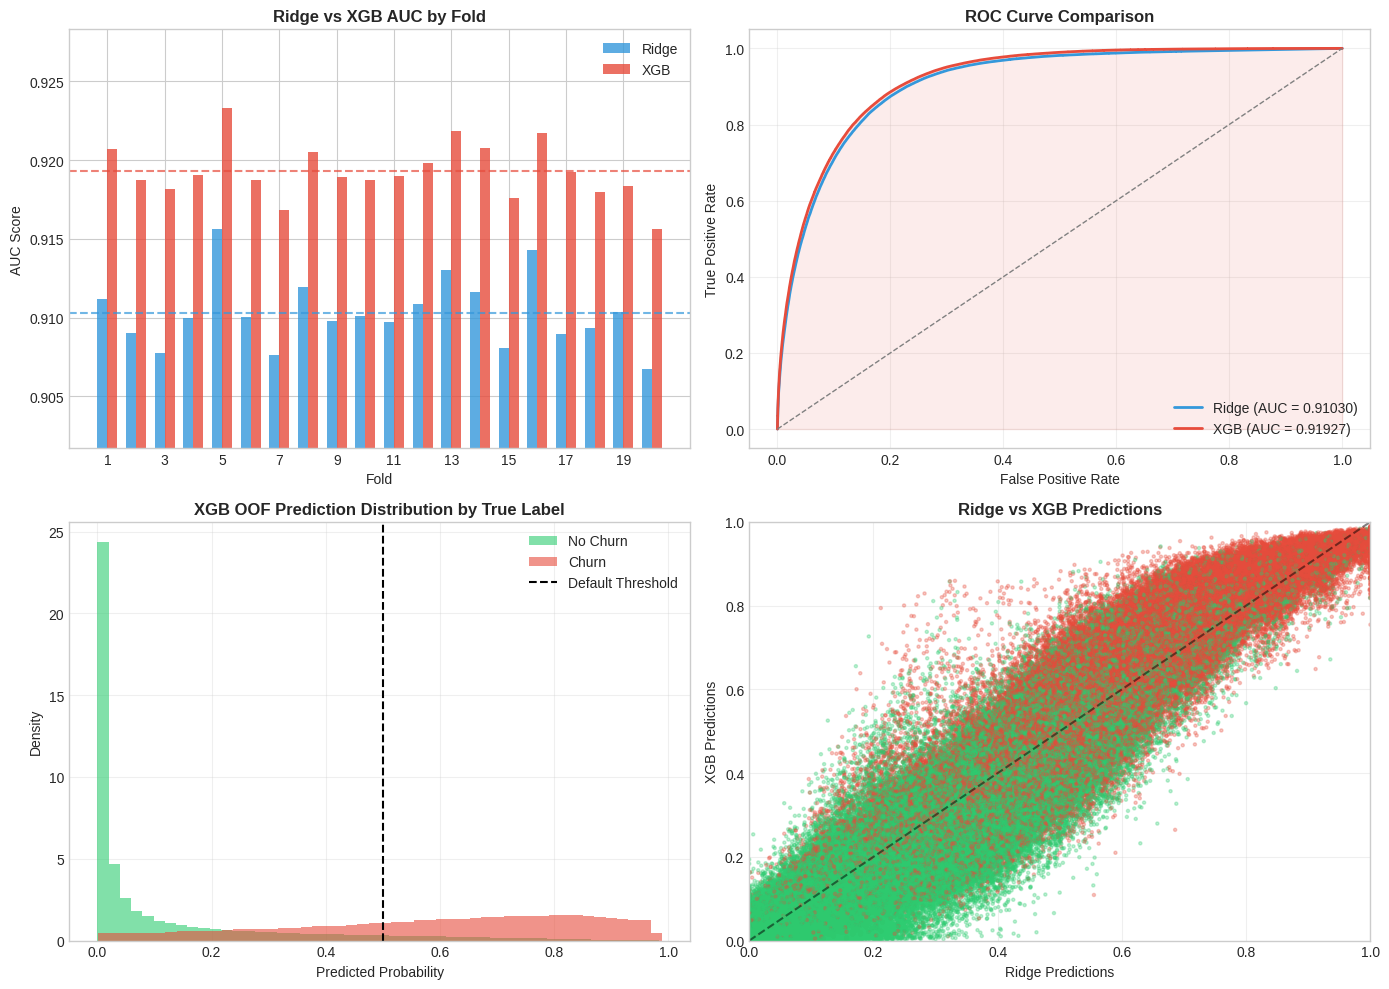

In [23]:
# Visualization: Fold Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fold AUC Scores - Ridge vs XGB
ax1 = axes[0, 0]
x_pos = np.arange(1, CFG.N_FOLDS + 1)
width = 0.35
bars1 = ax1.bar(x_pos - width/2, ridge_fold_scores, width, label='Ridge', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, xgb_fold_scores, width, label='XGB', color='#e74c3c', alpha=0.8)
ax1.axhline(y=ridge_mean, color='#3498db', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.axhline(y=xgb_mean, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_xlabel('Fold')
ax1.set_ylabel('AUC Score')
ax1.set_title('Ridge vs XGB AUC by Fold', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos[::2])
ax1.legend()
ax1.set_ylim([min(min(ridge_fold_scores), min(xgb_fold_scores)) - 0.005, 
              max(max(ridge_fold_scores), max(xgb_fold_scores)) + 0.005])

# 2. ROC Curve
ax2 = axes[0, 1]
fpr_r, tpr_r, _ = roc_curve(train[CFG.TARGET], ridge_oof)
fpr_x, tpr_x, _ = roc_curve(train[CFG.TARGET], xgb_oof)
ax2.plot(fpr_r, tpr_r, color='#3498db', linewidth=2, label=f'Ridge (AUC = {ridge_overall_auc:.5f})')
ax2.plot(fpr_x, tpr_x, color='#e74c3c', linewidth=2, label=f'XGB (AUC = {xgb_overall_auc:.5f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
ax2.fill_between(fpr_x, tpr_x, alpha=0.1, color='#e74c3c')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve Comparison', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# 3. Prediction Distribution
ax3 = axes[1, 0]
ax3.hist(xgb_oof[train[CFG.TARGET] == 0], bins=50, alpha=0.6, label='No Churn', color='#2ecc71', density=True)
ax3.hist(xgb_oof[train[CFG.TARGET] == 1], bins=50, alpha=0.6, label='Churn', color='#e74c3c', density=True)
ax3.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold')
ax3.set_xlabel('Predicted Probability')
ax3.set_ylabel('Density')
ax3.set_title('XGB OOF Prediction Distribution by True Label', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Ridge vs XGB Scatter
ax4 = axes[1, 1]
ax4.scatter(ridge_oof, xgb_oof, alpha=0.3, s=5, c=train[CFG.TARGET].map({0: '#2ecc71', 1: '#e74c3c'}))
ax4.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax4.set_xlabel('Ridge Predictions')
ax4.set_ylabel('XGB Predictions')
ax4.set_title('Ridge vs XGB Predictions', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.set_xlim([0, 1])
ax4.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

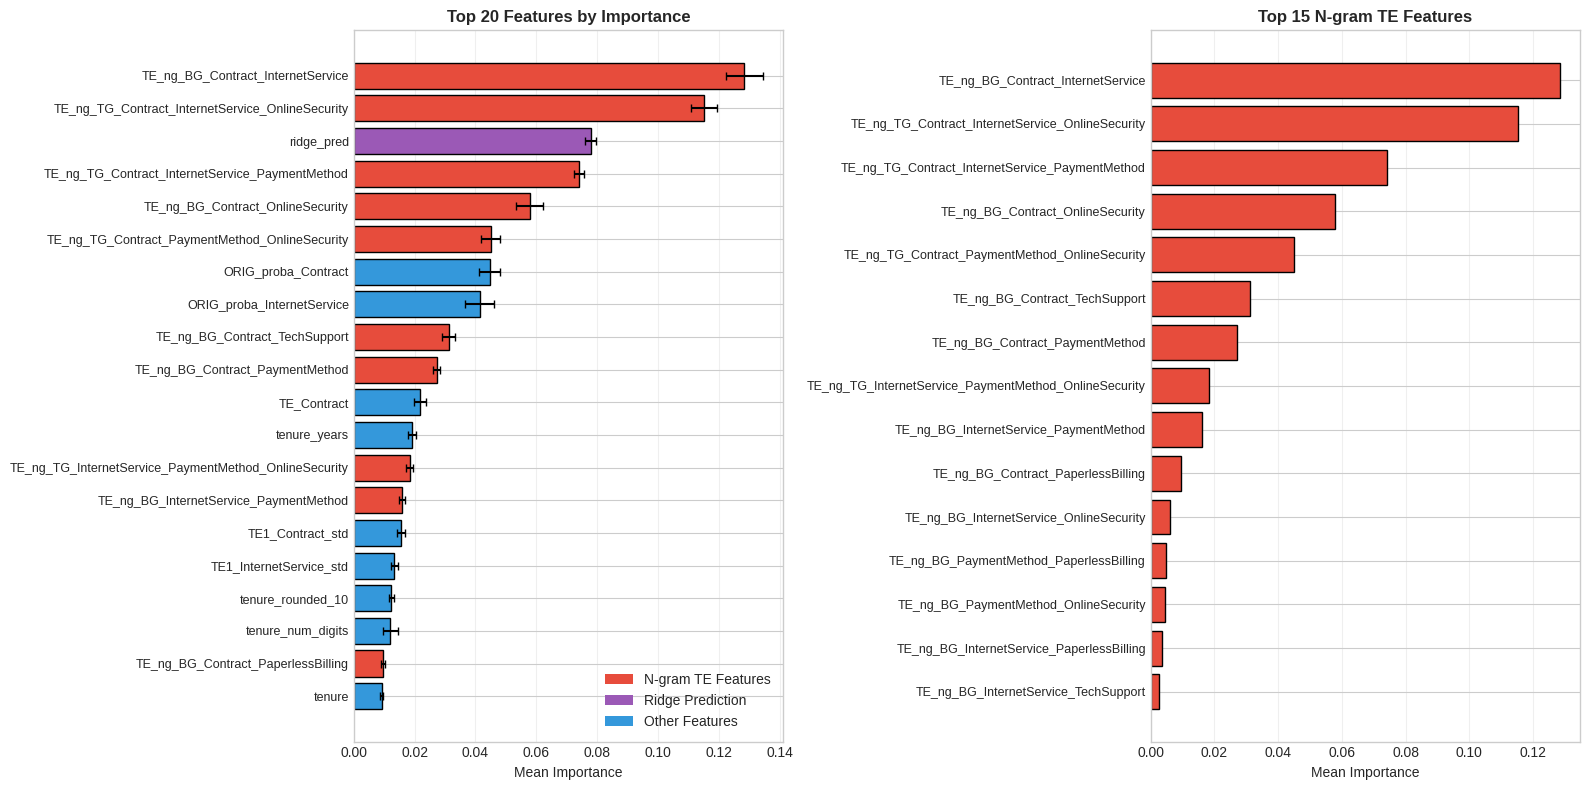


Top 15 Features by Importance:
------------------------------------------------------------
  TE_ng_BG_Contract_InternetService             0.1283
  TE_ng_TG_Contract_InternetService_OnlineSecurity 0.1152
  ridge_pred                                    0.0779 <-- Ridge Prediction
  TE_ng_TG_Contract_InternetService_PaymentMethod 0.0741
  TE_ng_BG_Contract_OnlineSecurity              0.0578
  TE_ng_TG_Contract_PaymentMethod_OnlineSecurity 0.0450
  ORIG_proba_Contract                           0.0447
  ORIG_proba_InternetService                    0.0414
  TE_ng_BG_Contract_TechSupport                 0.0312
  TE_ng_BG_Contract_PaymentMethod               0.0272
  TE_Contract                                   0.0219
  tenure_years                                  0.0192
  TE_ng_TG_InternetService_PaymentMethod_OnlineSecurity 0.0184
  TE_ng_BG_InternetService_PaymentMethod        0.0159
  TE1_Contract_std                              0.0156


In [24]:
# Feature Importance Analysis
# Calculate mean importance across folds
imp_cols = [c for c in feature_importances.columns if c.startswith('importance_fold')]
feature_importances['mean_importance'] = feature_importances[imp_cols].mean(axis=1)
feature_importances['std_importance'] = feature_importances[imp_cols].std(axis=1)
feature_importances = feature_importances.sort_values('mean_importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 features overall
ax1 = axes[0]
top20 = feature_importances.head(20)
colors = ['#e74c3c' if 'TE_ng_' in f else '#9b59b6' if 'ridge_pred' in f else '#3498db' for f in top20['feature']]
bars = ax1.barh(range(len(top20)), top20['mean_importance'], xerr=top20['std_importance'], 
               color=colors, edgecolor='black', capsize=3)
ax1.set_yticks(range(len(top20)))
ax1.set_yticklabels(top20['feature'], fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Mean Importance')
ax1.set_title('Top 20 Features by Importance', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='N-gram TE Features'),
                   Patch(facecolor='#9b59b6', label='Ridge Prediction'),
                   Patch(facecolor='#3498db', label='Other Features')]
ax1.legend(handles=legend_elements, loc='lower right')

# Top 15 N-gram features
ax2 = axes[1]
ngram_imp = feature_importances[feature_importances['feature'].str.startswith('TE_ng_')].head(15)
if len(ngram_imp) > 0:
    bars = ax2.barh(range(len(ngram_imp)), ngram_imp['mean_importance'], 
                   color='#e74c3c', edgecolor='black')
    ax2.set_yticks(range(len(ngram_imp)))
    ax2.set_yticklabels(ngram_imp['feature'], fontsize=9)
    ax2.invert_yaxis()
ax2.set_xlabel('Mean Importance')
ax2.set_title('Top 15 N-gram TE Features', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top features including ridge_pred
print("\nTop 15 Features by Importance:")
print("-"*60)
for i, row in feature_importances.head(15).iterrows():
    marker = " <-- Ridge Prediction" if 'ridge_pred' in row['feature'] else ""
    print(f"  {row['feature']:45s} {row['mean_importance']:.4f}{marker}")

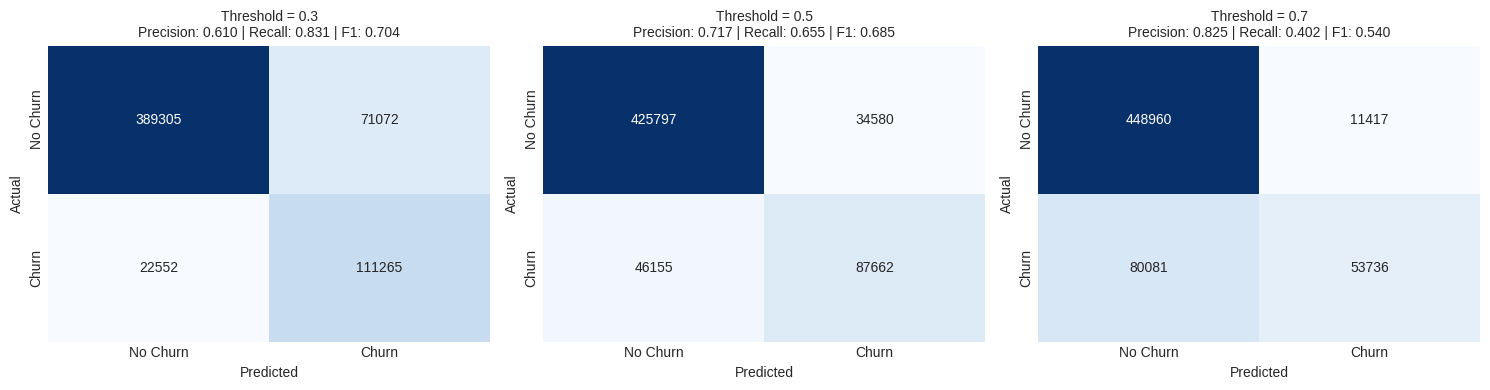


Note: Lower threshold = higher recall (catch more churners)
      Higher threshold = higher precision (more confident predictions)


In [25]:
# Confusion Matrix at Different Thresholds
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
thresholds = [0.3, 0.5, 0.7]

for ax, thresh in zip(axes, thresholds):
    y_pred = (xgb_oof >= thresh).astype(int)
    cm = confusion_matrix(train[CFG.TARGET], y_pred)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Threshold = {thresh}\nPrecision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}', 
                fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: Lower threshold = higher recall (catch more churners)")
print("      Higher threshold = higher precision (more confident predictions)")

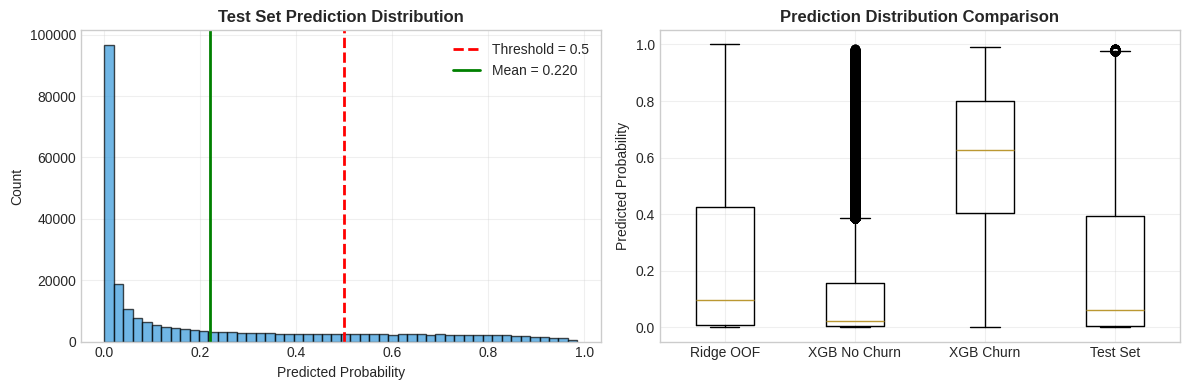


Test Set Statistics:
  Mean prediction: 0.2199
  Std prediction:  0.2796
  Min prediction:  0.0001
  Max prediction:  0.9853
  Predicted churn rate (threshold=0.5): 19.72%


In [26]:
# Test Set Prediction Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(xgb_pred, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold = 0.5')
axes[0].axvline(x=np.mean(xgb_pred), color='green', linestyle='-', linewidth=2, label=f'Mean = {np.mean(xgb_pred):.3f}')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Test Set Prediction Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot comparison
axes[1].boxplot([ridge_oof, xgb_oof[train[CFG.TARGET] == 0], xgb_oof[train[CFG.TARGET] == 1], xgb_pred],
               labels=['Ridge OOF', 'XGB No Churn', 'XGB Churn', 'Test Set'])
axes[1].set_ylabel('Predicted Probability')
axes[1].set_title('Prediction Distribution Comparison', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTest Set Statistics:")
print(f"  Mean prediction: {np.mean(xgb_pred):.4f}")
print(f"  Std prediction:  {np.std(xgb_pred):.4f}")
print(f"  Min prediction:  {np.min(xgb_pred):.4f}")
print(f"  Max prediction:  {np.max(xgb_pred):.4f}")
print(f"  Predicted churn rate (threshold=0.5): {(xgb_pred >= 0.5).mean()*100:.2f}%")

---
## 7. Saving Predictions

Save Out-of-Fold predictions and test set predictions for submission.

In [27]:
# Save Ridge predictions
ridge_oof_df = pd.DataFrame({
    'id': train_ids,
    CFG.TARGET: ridge_oof
})
ridge_oof_df.to_csv('oof_ridge.csv', index=False)
print(f"Ridge OOF saved to 'oof_ridge.csv'")
print(f"  Shape: {ridge_oof_df.shape}")
display(ridge_oof_df.head())

ridge_sub_df = pd.DataFrame({
    'id': test_ids,
    CFG.TARGET: ridge_pred
})
ridge_sub_df.to_csv('submission_ridge.csv', index=False)
print(f"\nRidge submission saved to 'submission_ridge.csv'")
print(f"  Shape: {ridge_sub_df.shape}")

# Save XGB predictions (final)
xgb_oof_df = pd.DataFrame({
    'id': train_ids,
    CFG.TARGET: xgb_oof
})
xgb_oof_df.to_csv('oof_xgb.csv', index=False)
print(f"\nXGB OOF saved to 'oof_xgb.csv'")
print(f"  Shape: {xgb_oof_df.shape}")
display(xgb_oof_df.head())

xgb_sub_df = pd.DataFrame({
    'id': test_ids,
    CFG.TARGET: xgb_pred
})
xgb_sub_df.to_csv('submission.csv', index=False)
print(f"\nXGB submission saved to 'submission.csv' (final)")
print(f"  Shape: {xgb_sub_df.shape}")
display(xgb_sub_df.head())

Ridge OOF saved to 'oof_ridge.csv'
  Shape: (594194, 2)


,id,Churn
0,0,0.000000
1,1,0.000000
2,2,0.424821
3,3,0.866049
4,4,0.845521



Ridge submission saved to 'submission_ridge.csv'
  Shape: (254655, 2)

XGB OOF saved to 'oof_xgb.csv'
  Shape: (594194, 2)


,id,Churn
0,0,0.008911
1,1,0.001160
2,2,0.280411
3,3,0.660426
4,4,0.784384



XGB submission saved to 'submission.csv' (final)
  Shape: (254655, 2)


,id,Churn
0,594194,0.141505
1,594195,0.000710
2,594196,0.114719
3,594197,0.002229
4,594198,0.529136


### Key Success Factors

<div class="alert alert-success" style="border-radius: 8px; padding: 20px; margin: 15px 0; background: #ecfdf5; border: 1px solid #10b981;">
    <h4 style="margin-top: 0; color: #047857;">What Made This Solution Effective</h4>
    <ul style="color: #065f46; margin-bottom: 0;">
        <li><strong>Two-Stage Learning:</strong> Ridge captures linear patterns, XGB corrects non-linear mistakes</li>
        <li><strong>Bi-gram/Tri-gram Encoding:</strong> Captured 2-way and 3-way categorical interactions</li>
        <li><strong>Comprehensive Feature Engineering:</strong> 7-step pipeline created diverse predictive signals</li>
        <li><strong>Robust Validation:</strong> 20-fold stratified CV with inner 5-fold TE prevented overfitting</li>
        <li><strong>Original Data Leverage:</strong> Used real data for target encoding reference</li>
    </ul>
</div>

### Future Improvements

<div class="alert alert-warning" style="border-radius: 8px; padding: 20px; margin: 15px 0; background: #fffbeb; border: 1px solid #f59e0b;">
    <h4 style="margin-top: 0; color: #92400e;">Potential Enhancements</h4>
    <ul style="color: #78350f; margin-bottom: 0;">
        <li>Add LightGBM and CatBoost to the two-stage pipeline</li>
        <li>Neural tabular models (TabNet, FT-Transformer)</li>
        <li>Feature selection via SHAP analysis</li>
        <li>Stacking multiple model predictions</li>
        <li>Automated hyperparameter optimization (Optuna)</li>
    </ul>
</div>

---
<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 30px; border-radius: 12px; margin-top: 20px;">

<h3 style="color: #ffffff; margin-top: 0;">Solution Summary</h3>

<p style="color: #94a3b8; font-size: 14px;">
<strong style="color: #20beff;">Model Architecture:</strong> Two-Stage Ridge → XGBoost
</p>

<p style="color: #94a3b8; font-size: 14px;">
<strong style="color: #20beff;">Key Innovation:</strong> Ridge predictions used as feature for XGBoost, enabling the tree model to focus on non-linear corrections
</p>

<p style="color: #94a3b8; font-size: 14px;">
<strong style="color: #20beff;">Feature Engineering:</strong> 7-step pipeline including frequency encoding, distribution features, quantile distances, digit features, and N-gram encoding
</p>

<p style="color: #94a3b8; font-size: 14px;">
<strong style="color: #20beff;">Validation:</strong> 20-fold stratified cross-validation with inner 5-fold target encoding
</p>

<hr style="border: none; height: 1px; background: #374151; margin: 20px 0;">

<p style="color: #e2e8f0; font-size: 14px;">
This notebook demonstrates the effectiveness of two-stage learning for customer churn prediction. By first training a linear model (Ridge) and then using its predictions as a feature for a non-linear model (XGBoost), we achieve better performance than either model alone. The bi-gram and tri-gram features allow the model to learn joint effects of categorical variable combinations.
</p>

</div>